In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
T_a0 = 600
T_b0 = 500


density = 3e23
mass =  6.6464764e-27
mean_sigma_g_inter = 1e-20
mean_sigma_g_intra = 100 * mean_sigma_g_inter


nu_col_inter = density * mean_sigma_g_inter
nu_col_intra = density * mean_sigma_g_intra

rate_inter = density * nu_col_inter
rate_intra = 0.5 * density * nu_col_intra

In [3]:
def T_alpha_true(t, T_a=T_a0, T_b=T_b0, inter_nu=nu_col_inter):
  return (T_a + T_b) / 2 + (T_a - T_b) / 2 * np.exp(-inter_nu * t)

def T_beta_true(t, T_a=T_a0, T_b=T_b0, inter_nu=nu_col_inter):
  return (T_a + T_b) / 2 - (T_a - T_b) / 2 * np.exp(-inter_nu * t)

1 Simulations Failed

Expected Intra Rate : 4.5000E+28 m^-3 s^-1
Alpha-Alpha Rate    : 4.4977E+28 +- 2.6845E+26 m^-3 s^-1
Alpha-Alpha Error   : 5.0421E-02 %
Beta-Beta Rate      : 4.4977E+28 +- 2.6723E+26 m^-3 s^-1
Beta-Beta Error     : 5.0526E-02 %

Expected Inter Rate : 9.0000E+26 m^-3 s^-1
Alpha-Beta Rate     : 9.0136E+26 +- 2.9756E+26 m^-3 s^-1
Alpha-Beta Error    : 1.5132E-01 %


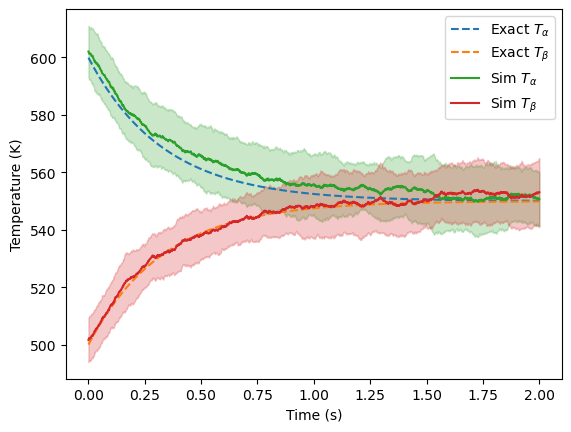

In [4]:
show_all = False
runs = 20
all_T_alpha = None
all_T_beta = None
all_alpha_alpha_rate = None
all_beta_beta_rate = None
all_alpha_beta_rate = None

num_steps = None

plt.figure()
fails = 0
for i in range(runs):
    data = pd.read_csv(f"data/run_{i}.csv")

    time = data["time"].to_numpy()[1:] * 1e3
    T_alpha = data["T_alpha"].to_numpy()[1:]
    T_beta = data["T_beta"].to_numpy()[1:]

    if i == 0:
      num_steps = len(time)

      all_T_alpha = np.zeros((runs, num_steps))
      all_T_beta = np.zeros_like(all_T_alpha)
      all_alpha_alpha_rate = np.zeros_like(all_T_alpha)
      all_beta_beta_rate = np.zeros_like(all_T_alpha)
      all_alpha_beta_rate = np.zeros_like(all_T_alpha)


    if len(T_alpha) != num_steps:
        fails += 1
        continue
    if show_all:
        plt.plot(time, T_alpha)
        plt.plot(time, T_beta)

    all_T_alpha[i - fails, :] = T_alpha
    all_T_beta[i - fails, :] = T_beta
    all_alpha_alpha_rate[i - fails, :] = data["alpha_rate"].to_numpy()[1:]
    all_beta_beta_rate[i - fails, :] = data["beta_rate"].to_numpy()[1:]
    all_alpha_beta_rate[i - fails, :] = data["alpha_beta_rate"].to_numpy()[1:]

print(f"{fails:d} Simulations Failed")
print()
alpha_rate_mean = all_alpha_alpha_rate[:-fails].mean()
beta_rate_mean = all_beta_beta_rate[:-fails].mean()
alpha_beta_rate_mean = all_alpha_beta_rate[:-fails].mean()

alpha_rate_std = all_alpha_alpha_rate[:-fails].std()
beta_rate_std = all_beta_beta_rate[:-fails].std()
alpha_beta_rate_std = all_alpha_beta_rate[:-fails].std()

print(f"Expected Intra Rate : {rate_intra:0.4E} m^-3 s^-1")
print(f"Alpha-Alpha Rate    : {alpha_rate_mean:0.4E} +- {2 * alpha_rate_std:0.4E} m^-3 s^-1")
print(f"Alpha-Alpha Error   : {np.abs(alpha_rate_mean - rate_intra) / rate_intra * 100:0.4E} %")
print(f"Beta-Beta Rate      : {beta_rate_mean:0.4E} +- {2 * beta_rate_std:0.4E} m^-3 s^-1")
print(f"Beta-Beta Error     : {np.abs(beta_rate_mean - rate_intra) / rate_intra * 100:0.4E} %")
print()
print(f"Expected Inter Rate : {rate_inter:0.4E} m^-3 s^-1")
print(f"Alpha-Beta Rate     : {alpha_beta_rate_mean:0.4E} +- {2 * alpha_beta_rate_std:0.4E} m^-3 s^-1")
print(f"Alpha-Beta Error    : {np.abs(alpha_beta_rate_mean - rate_inter) / rate_inter * 100:0.4E} %")

T_alpha_mean = all_T_alpha[:-fails].mean(axis=0)
T_alpha_std = all_T_alpha[:-fails].std(axis=0)
T_beta_mean =  all_T_beta[:-fails].mean(axis=0)
T_beta_std = all_T_beta[:-fails].std(axis=0)

plt.plot(time, T_alpha_true(time * 1e-3), '--', label='Exact $T_\\alpha$')
plt.plot(time, T_beta_true(time * 1e-3), '--', label='Exact $T_\\beta$')
plt.plot(time, T_alpha_mean, label='Sim $T_\\alpha$')
plt.plot(time, T_beta_mean, label='Sim $T_\\beta$')
plt.fill_between(time, T_alpha_mean  - T_alpha_std, T_alpha_mean + T_alpha_std, color='tab:green', alpha=0.25)
plt.fill_between(time, T_beta_mean  - T_beta_std, T_beta_mean + T_beta_std, color='tab:red', alpha=0.25)
plt.legend()
plt.xlabel("Time (s)")
plt.ylabel("Temperature (K)")
plt.show()


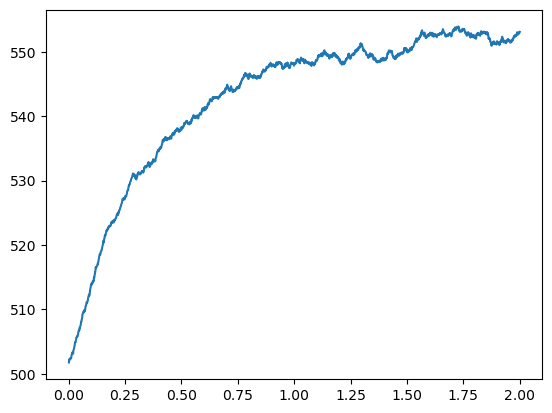

In [14]:
plt.figure()
plt.plot(time, T_beta_mean)
plt.show()